In [1]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

from Utils import to_sin,to_radians,to_cos, hour_to_sin, hour_to_cos, calculate_global_moran, calculate_bearing


In [2]:
dataset = pd.read_csv("../data/january_h.csv")

In [3]:
data = dataset.loc[:, ['s_date', 's_hour', 
                       'day_of_week',
                #        'week_of_month',
       'weekend_or_weekday_sdate', 'count', 
        'is_holiday',
       'time_of_day',
        'start_station_number', 'longitude', 'latitude', 'cafe_count_5min_walk', 'bank_count_5min_walk',
        'university_count_5min_walk', 'pub_count_5min_walk', 'railway_station_count_5min_walk',
        'dist_to_nearest_cafe','dist_to_nearest_university','dist_to_nearest_pub','dist_to_nearest_bank',
        'dist_to_nearest_railway_station']]

data = data.astype({"s_date":"object",
                    # "s_hour":"object", #dont do this if using sin
                    "day_of_week":"object",
                #     "week_of_month":"object",
                    "weekend_or_weekday_sdate":"object",
                    "is_holiday":"object",
                    "time_of_day":"object",
                    "count":"int",
                    "start_station_number":"object"
                    })



In [4]:
numerical_features = ['bank_count_5min_walk',
        'university_count_5min_walk', 'pub_count_5min_walk', 'railway_station_count_5min_walk',
        'dist_to_nearest_cafe','dist_to_nearest_university','dist_to_nearest_pub','dist_to_nearest_bank',
        'dist_to_nearest_railway_station']

In [5]:
data.head()

,s_date,s_hour,day_of_week,weekend_or_weekday_sdate,count,is_holiday,time_of_day,start_station_number,longitude,latitude,cafe_count_5min_walk,bank_count_5min_walk,university_count_5min_walk,pub_count_5min_walk,railway_station_count_5min_walk,dist_to_nearest_cafe,dist_to_nearest_university,dist_to_nearest_pub,dist_to_nearest_bank,dist_to_nearest_railway_station
0,2023-01-01,23,6,weekend,1,False,night,3425,-0.114079,51.522264,12,1,0,6,0,33.203681,416.639834,95.733029,138.461838,557.171518
1,2023-01-01,23,6,weekend,1,False,night,3499,-0.176416,51.499807,3,0,0,3,0,410.779493,28.868061,112.848715,949.262299,1051.679401
2,2023-01-01,23,6,weekend,2,False,night,300092,-0.079202,51.537278,4,0,0,0,0,112.822028,1208.890929,312.915101,1604.680291,535.631025
3,2023-01-01,23,6,weekend,2,False,night,300029,-0.015718,51.549369,1,0,0,0,0,126.462967,1726.609745,648.970641,1187.204348,972.001055
4,2023-01-01,23,6,weekend,1,False,night,300052,-0.201968,51.475089,3,0,0,0,0,129.574737,948.294162,233.067499,413.392571,0.000000


In [6]:
data['s_date'] = pd.to_datetime(data['s_date'], dayfirst=False, errors='coerce')

min_date = data['s_date'].min()
max_date = data['s_date'].max()
print(f"Dataset Range: {min_date} to {max_date}")

cutoff_date = max_date - pd.Timedelta(days=7)
print(f"Cutoff Date (Max - 7 days): {cutoff_date}")

train_data = data[data['s_date'] < cutoff_date].copy()
test_data = data[data['s_date'] >= cutoff_date].copy()
print(f"Training data rows: {len(train_data)}")
print(f"Test data rows: {len(test_data)}")

Dataset Range: 2023-01-01 00:00:00 to 2023-01-31 00:00:00
Cutoff Date (Max - 7 days): 2023-01-24 00:00:00
Training data rows: 432768
Test data rows: 150528


In [7]:
X_train = train_data.drop("count", axis=1).copy()
y_train = train_data["count"].copy()

X_test = test_data.drop("count", axis=1).copy()
y_test = test_data["count"].copy()


In [8]:
def return_input_names(transformer, input_features):
    return input_features


sin_transformer = Pipeline([
    ('radians', FunctionTransformer(to_radians, feature_names_out=return_input_names)),
    ('sin', FunctionTransformer(to_sin, feature_names_out=return_input_names))
])

cos_transformer = Pipeline([
    ('radians', FunctionTransformer(to_radians, feature_names_out=return_input_names)),
    ('cos', FunctionTransformer(to_cos, feature_names_out=return_input_names))
])

sin_hour_transformer = Pipeline([
    ('hour_sin', FunctionTransformer(hour_to_sin, feature_names_out=return_input_names))
])
cos_hour_transformer = Pipeline([
    ("hour_cos", FunctionTransformer(hour_to_cos, feature_names_out=return_input_names))
])


preprocessor = ColumnTransformer(
    transformers=[
        
        ('time_of_day_ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['time_of_day']),
        ('day_of_week_ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['day_of_week']),
        ('is_holiday_ohe', OneHotEncoder(drop='first', sparse_output=False), ['is_holiday']),
        ('weekend_or_weekday_sdate_ohe', OneHotEncoder(drop='first', sparse_output=False), ['weekend_or_weekday_sdate']),
        
        ('s_hour_sin', sin_hour_transformer, ['s_hour']),
        ('s_hour_cos', cos_hour_transformer, ['s_hour']),
        ('num', 'passthrough', numerical_features)
       
    ],
    
    # 'passthrough' keeps them. 'drop' deletes them.
    remainder='drop' 
)

In [9]:
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),  
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

In [10]:
X_train.columns

Index(['s_date', 's_hour', 'day_of_week', 'weekend_or_weekday_sdate',
       'is_holiday', 'time_of_day', 'start_station_number', 'longitude',
       'latitude', 'cafe_count_5min_walk', 'bank_count_5min_walk',
       'university_count_5min_walk', 'pub_count_5min_walk',
       'railway_station_count_5min_walk', 'dist_to_nearest_cafe',
       'dist_to_nearest_university', 'dist_to_nearest_pub',
       'dist_to_nearest_bank', 'dist_to_nearest_railway_station'],
      dtype='object')

In [11]:
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('time_of_day_ohe',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['time_of_day']),
                                                 ('day_of_week_ohe',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['day_of_week']),
                                                 ('is_holiday_ohe',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['is_holiday']),
                                                 ('weekend_or_w...
                                                                                       func=<function hour_to_cos at 0x000002013962E480>))]),
                                                  ['s_hour']),
                                                 ('num', 'passthrough',
                                                  ['bank_count_5min_walk',
                                                   'university_count_5min_walk',
                                                   'pub_count_5min_walk',
                                                   'railway_station_count_5min_walk',
                                                   'dist_to_nearest_cafe',
                                                   'dist_to_nearest_university',
                                                   'dist_to_nearest_pub',
                                                   'dist_to_nearest_bank',
                                                   'dist_to_nearest_railway_station'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [12]:
y_train_pred = model_pipeline.predict(X_train)
y_test_pred = model_pipeline.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Training R2: {train_r2:.4f}")
print(f"Test R2:     {test_r2:.4f}")

Training R2: 0.6982
Test R2:     0.5472


In [13]:
model = model_pipeline.named_steps['model']

preprocessor_1 = model_pipeline.named_steps['preprocessor']
feature_names = preprocessor_1.get_feature_names_out()

importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

In [14]:
print(importance)

                                              Feature  Importance
14                                 s_hour_cos__s_hour    0.166241
22                          num__dist_to_nearest_bank    0.111067
13                                 s_hour_sin__s_hour    0.091181
19                          num__dist_to_nearest_cafe    0.083939
23               num__dist_to_nearest_railway_station    0.082260
21                           num__dist_to_nearest_pub    0.079632
20                    num__dist_to_nearest_university    0.078659
12  weekend_or_weekday_sdate_ohe__weekend_or_weekd...    0.053108
17                           num__pub_count_5min_walk    0.030497
8                      day_of_week_ohe__day_of_week_4    0.025083
4                      day_of_week_ohe__day_of_week_0    0.024872
7                      day_of_week_ohe__day_of_week_3    0.022858
6                      day_of_week_ohe__day_of_week_2    0.022477
11                    is_holiday_ohe__is_holiday_True    0.022470
2         

In [15]:
analysis_df = X_test.copy()

analysis_df['actual_count'] = y_test

analysis_df['predicted_count'] = y_test_pred

analysis_df['residual'] = analysis_df['actual_count'] - analysis_df['predicted_count']

In [16]:
analysis_df["residual"].head()

413952   -0.774794
413953   -0.499750
413954   -0.526238
413955   -0.491421
413956   -0.298783
Name: residual, dtype: float64

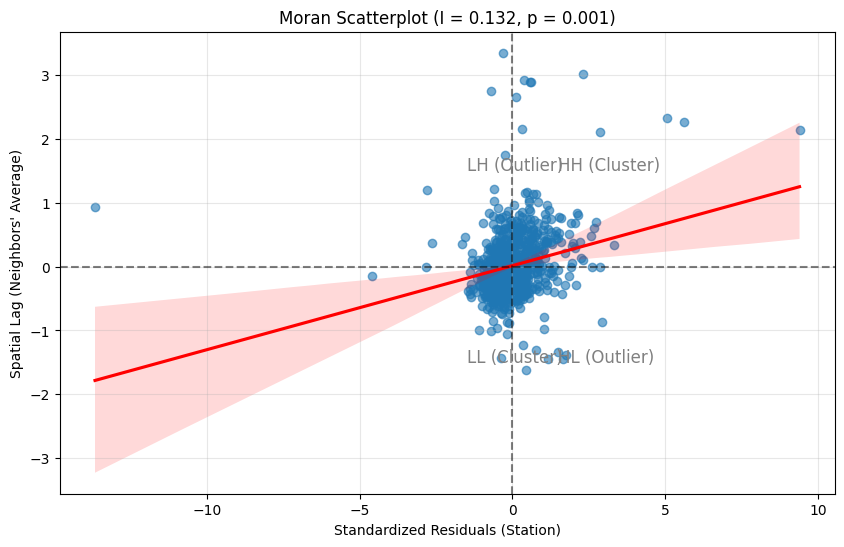

In [17]:
moran = calculate_global_moran(analysis_df, "residual", "start_station_number", "latitude", "longitude", k=8, plot=True)

In [18]:
moran[0]

{"Moran's I": 0.13152568509983545,
 'p-value': 0.001,
 'z-score': 8.445084221071077,
 'conclusion(p_value)': 'The residuals are clustered (p <= 0.05)'}